In [4]:
import MDAnalysis as mda
from numpy import *
import os
from pylab import *
import MDAnalysis.analysis.distances
import MDAnalysis.analysis.rms
from MDAnalysis.analysis import align
import glob
#import umap
import scipy.stats
import sklearn
import sklearn.decomposition
import sklearn.preprocessing
import pandas as pd
import seaborn as sns
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA

In [5]:
import os

########################################################
#############      FOR NOW EQPOINT IS 0   ##############
########################################################
EQPOINT=0

systemFolders = glob.glob("huNumbering/*t5a*/")

systemgros=[]
systemtprs=[]
systemtrjs=[]
for i in range(len(systemFolders)):
    systemgros.append(sorted(glob.glob(systemFolders[i]+"*.gro")))
    systemtprs.append(sorted(glob.glob(systemFolders[i]+"*.tpr")))
    systemtrjs.append(sorted(glob.glob(systemFolders[i]+"*.xtc")))


    
    
threeColor=["#FE6100","#332288","#882255"]
colourScheme= threeColor
system_names = ["rhT5A","T5A","T5AR332P"]
systems=[]
for i in range(len(systemgros)):
    sub=[]
    for j in range(len(systemgros[i])):
        # When using TPRs, residues are indexed from 1; so we need to add in the first residue, 1 - 1 + first resid=first resid
        #firstres = mda.Universe(systemgros[i][j]).residues.resids[0]-1
        tu = mda.Universe(systemgros[i][j],systemtrjs[i][j])
        #tu.residues.resids +=firstres
                          
        sub.append(tu)
        
    systems.append(sub)


bodys=[]
bodystrings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and not ("+combinedLoopString+")"))
        sub2.append("protein and not ("+combinedLoopString+")")
        
    bodys.append(sub)
    bodystrings.append(sub2)
    
    
v1s=[]
v1strings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v1s.append(sub)        
    v1strings.append(sub2)
                   

In [6]:
# Ok let's do PCA
def getPairwiseDists(systems,datasets,selection_strings,stride = 10,EQPOINT=250):
    
    alldists=[]
    for i in range(len(datasets)):
        subdists=[]
        for j in range(len(datasets[i])):
            distances=[]
            for k in range(int(EQPOINT/stride),int(len(systems[i][j].trajectory)/stride)):
                systems[i][j].trajectory[k*stride]
                distances.append(MDAnalysis.analysis.distances.self_distance_array(datasets[i][j].select_atoms("name CA").positions))
            subdists.append(distances)
        alldists.append(subdists)
    return alldists


In [9]:

dists = getPairwiseDists(systems[1:],v1s[1:],v1strings[1:],stride = 10,EQPOINT=EQPOINT)







In [10]:
#save("allpcadists-V1-CApairwise.npy",dists)
#dists=load("allpcadists-V1-CApairwise.npy")

shaped_dists=[]
pca_colours = []
for i in range(len(dists)):
    for j in range(len(dists[i])):
        for k in range(len(dists[i][j])):
            shaped_dists.append(dists[i][j][k])
            pca_colours.append(colourScheme[i+1])
            
            

Z=sklearn.preprocessing.StandardScaler().fit_transform(shaped_dists)

myPCA=sklearn.decomposition.PCA(n_components=2)
myfit=myPCA.fit(Z)
pcaX=myPCA.transform(Z)
pcaPoints= pcaX.T

In [12]:
#Create a scaler
scaler = sklearn.preprocessing.StandardScaler()
# Fit scaler with the distances from the structures
scaler.fit(shaped_dists)
# get the mean and scale of this transformation
scale_final = scaler.scale_
mean_final = scaler.mean_


scaled_dists = (copy(dists) - mean_final)/scale_final
transformed_dists = []
for i in range(len(scaled_dists)):
    sub=[]
    for j in range(len(scaled_dists[i])):
        sub.append(myPCA.transform(scaled_dists[i][j]))
        
    transformed_dists.append(sub)

Text(0.5, 1.0, 'WT')

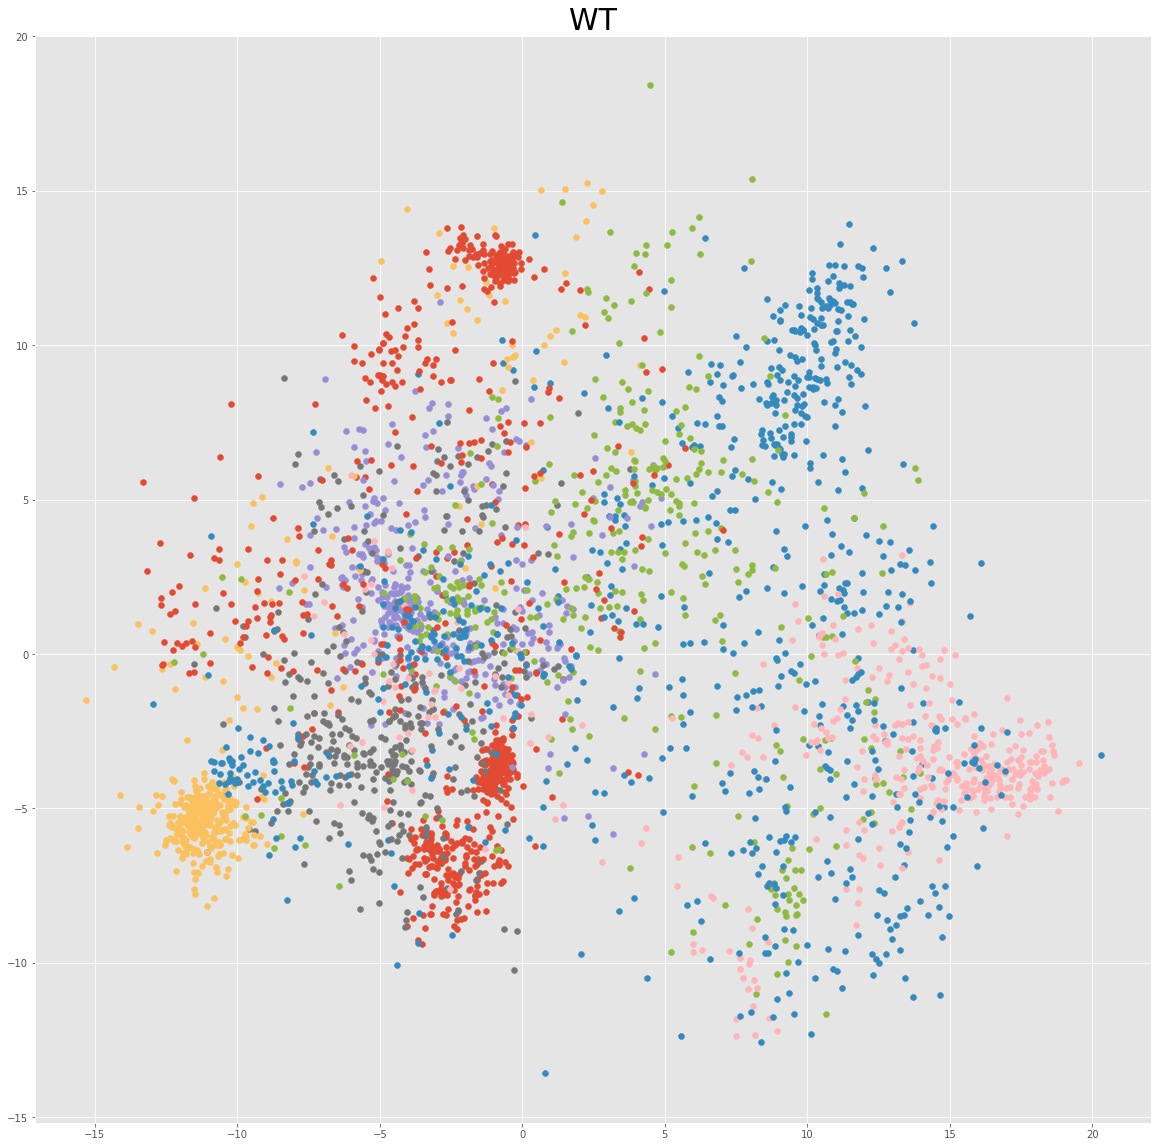

In [14]:
figure(figsize = (20,20))
for i in range(len(transformed_dists[0])):
    scatter(transformed_dists[0][i].T[0],transformed_dists[0][i].T[1])
title("WT", fontsize = 30)

Text(0.5, 1.0, 'R332P')

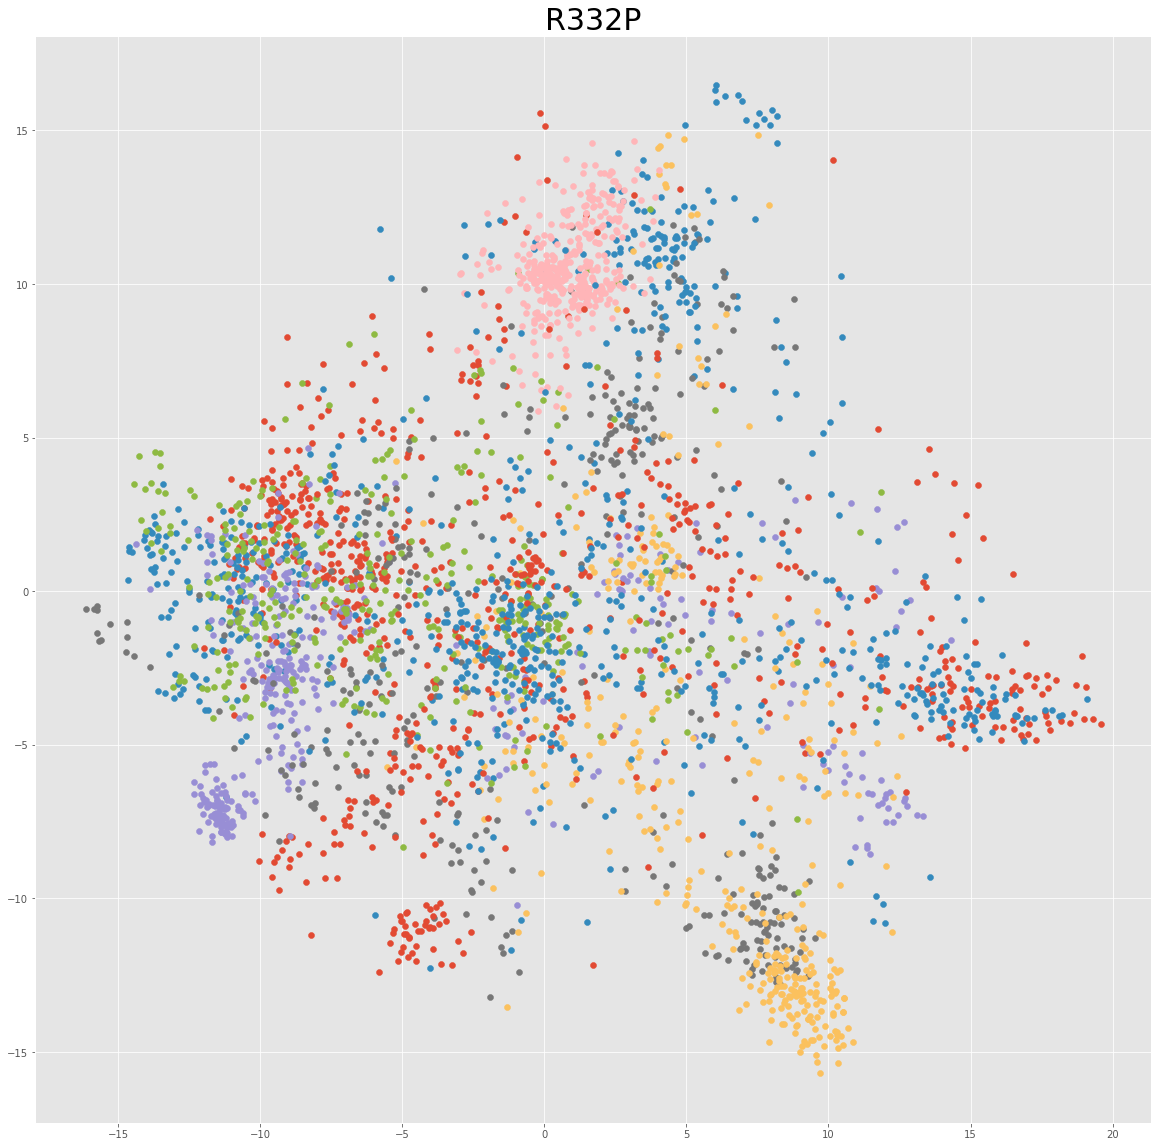

In [16]:
figure(figsize = (20,20))
for i in range(len(transformed_dists[1])):
    scatter(transformed_dists[1][i].T[0],transformed_dists[1][i].T[1])
title("R332P", fontsize = 30)

In [19]:
myPCA.explained_variance_ratio_

array([0.25828781, 0.17078128])

In [18]:
len(dists)

2